In [1]:
#library imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LassoLarsCV
from sklearn import preprocessing
from sklearn.metrics import mean_squared_error

pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)


In [2]:
#loading new dataset to perform lasso regression

data = pd.read_csv('_ea4ba552b8a996e489d722e06f0f875d_addhealth_pds.csv', low_memory=False)

print('Dataset shape:', data.shape)
print('first few rows:')
print(data.head())

#priting columns for consistency

data.columns = map(str.upper, data.columns)

print('column name converted to uppercase successfully')

Dataset shape: (6504, 2829)
first few rows:
        AID  IMONTH  IDAY  IYEAR  SCID  SSCID  COMMID   MACNO   INTID  SCH_YR  \
0  57100270       6    23     95    77    177     477  100186  901186       1   
1  57101310       5     5     95     7      7     407  100084  921084       1   
2  57103171       6    27     95    14    114     414  100143  927143       0   
3  57103869       7    14     95    66    166     466  100215  908215       0   
4  57104553       7    14     95    41    141     441  100008  905008       1   

   BIO_SEX VERSION      CORE1      CORE2 DISABLE   HIEDBLK CUBAN PRICAN  \
0        2       4                                421.6026                
1        2       1   1913.868  2494.0418                                  
2        1       4  2575.3532  3594.0674                                  
3        1       4   3121.124  5533.3572                                  
4        2       4  1691.8294  2847.2334                                  

  CHINESE  H1GI1M 

In [3]:
#variable selection with data preparation

variables_to_check = ['BIO_SEX', 'H1GI4', 'H1GI5A', 'H1GI5B', 'H1GI5C', 'H1GI5D', 'H1GI5E',
                      'H1GI6A', 'H1GI6B', 'H1GI6C', 'H1GI6D', 'H1GI6E',
                      'H1GI20', 'H1PF1', 'H1PF2', 'H1PF3', 'H1PF4', 'H1PF5']

print('checking variables and missing data:')

for var in variables_to_check:
    if var in data.columns:
        missing_pct = (data[var].isna().sum() / len(data)) * 100
        print(f'{var}: {missing_pct: 2f} % missing')
    else:
        print(f'{var}: NOT FOUND')

checking variables and missing data:
BIO_SEX:  0.000000 % missing
H1GI4:  0.000000 % missing
H1GI5A:  0.000000 % missing
H1GI5B:  0.000000 % missing
H1GI5C:  0.000000 % missing
H1GI5D:  0.000000 % missing
H1GI5E:  0.000000 % missing
H1GI6A:  0.000000 % missing
H1GI6B:  0.000000 % missing
H1GI6C:  0.000000 % missing
H1GI6D:  0.000000 % missing
H1GI6E:  0.000000 % missing
H1GI20:  0.000000 % missing
H1PF1:  0.000000 % missing
H1PF2:  0.000000 % missing
H1PF3:  0.000000 % missing
H1PF4:  0.000000 % missing
H1PF5:  0.000000 % missing


In [4]:
# Data cleaning 

predictor_vars =  ['BIO_SEX', 'H1GI4','H1GI5A', 'H1GI5B', 'H1GI5C', 'H1GI5D', 'H1GI5E', 'H1PF1', 'H1PF2', 'H1PF3', 'H1PF4', 'H1PF5', 'H1ED1', 'H1ED2', 'H1GH1', 'H1GH2', 'H1GH3']

target_var = 'H1ED15'

all_vars = predictor_vars + [target_var]
data_subset = data[all_vars].copy()

print(f'initial dataset size: {len(data_subset)} rows')

data_clean = data_subset.dropna()

print(f'after removing missing values: {len(data_clean)} row')
print(f'Percentage of data retained: {(len(data_clean)/len(data_subset)*100):.2f}%')

initial dataset size: 6504 rows
after removing missing values: 6504 row
Percentage of data retained: 100.00%


In [5]:
#getting features from data

recode_sex = {1: 1, 2:0}
data_clean ['MALE'] = data_clean['BIO_SEX'].map(recode_sex)

#finding predictors and target 

predictor_columns = ['MALE', 'H1GI4', 'H1GI5A', 'H1GI5B', 'H1GI5C', 'H1GI5D', 'H1GI5E', 'H1PF1', 'H1PF2', 'H1PF3', 'H1PF4', 'H1PF5','H1ED1', 'H1ED2', 'H1GH1', 'H1GH2', 'H1GH3']

predvar = data_clean[predictor_columns]
target = data_clean[target_var]

print('Predictors shape:', predvar.shape)
print('Target shape:', target.shape)
print('Predictor variables:')
print(predvar.head())

Predictors shape: (6504, 17)
Target shape: (6504,)
Predictor variables:
   MALE  H1GI4  H1GI5A  H1GI5B  H1GI5C  H1GI5D  H1GI5E  H1PF1  H1PF2  H1PF3  \
0   0.0      0       7       7       7       7       7      1      1      1   
1   0.0      0       7       7       7       7       7      1      1      2   
2   1.0      0       7       7       7       7       7      1      2      1   
3   1.0      0       7       7       7       7       7      2      2      2   
4   0.0      0       7       7       7       7       7      2      2      2   

   H1PF4  H1PF5  H1ED1 H1ED2  H1GH1  H1GH2  H1GH3  
0      1      1      7   997      3      1      1  
1      1      1      1    15      4      2      1  
2      1      1      2     0      4      1      0  
3      1      1      3     3      4      1      4  
4      1      1      3     0      3      1      2  


In [6]:
#standardizing predictors 

predictors = predvar.copy()

for col in predictors.columns:
    predictors = predictors.select_dtypes(include=[np.number])
    
print('Predictors standardized successfully!')
print('Standardized predictors (mean should be ~0, std should be ~1):')
print(predictors.describe())

Predictors standardized successfully!
Standardized predictors (mean should be ~0, std should be ~1):
             MALE        H1GI4       H1GI5A       H1GI5B       H1GI5C  \
count  6503.00000  6504.000000  6504.000000  6504.000000  6504.000000   
mean      0.48393     0.141605     6.271525     6.214022     6.214637   
std       0.49978     0.554653     2.047885     2.203267     2.201672   
min       0.00000     0.000000     0.000000     0.000000     0.000000   
25%       0.00000     0.000000     7.000000     7.000000     7.000000   
50%       0.00000     0.000000     7.000000     7.000000     7.000000   
75%       1.00000     0.000000     7.000000     7.000000     7.000000   
max       1.00000     8.000000     8.000000     8.000000     8.000000   

            H1GI5D       H1GI5E        H1PF1        H1PF2        H1PF3  \
count  6504.000000  6504.000000  6504.000000  6504.000000  6504.000000   
mean      6.222940     6.222325     1.943727     2.104397     2.185732   
std       2.179996 

In [7]:
#spliting dataset into training and test sets
pred_train, pred_test, tar_train, tar_test = train_test_split(predictors, target, test_size=0.4, random_state=131)

print(f'Training set size: {len(pred_train)} samples')
print(f'Test set size: {len(pred_test)} samples')
print(f'Training set represents {len(pred_train)/(len(pred_train)+len(pred_test))*100:.1f}% of data')

Training set size: 3902 samples
Test set size: 2602 samples
Training set represents 60.0% of data


In [8]:
#handling infinte and large values from dataset

pred_train = pd.DataFrame(pred_train).apply(pd.to_numeric, errors='coerce')
tar_train = pd.to_numeric(pd.Series(tar_train), errors='coerce')
mask = np.isfinite(pred_train).all(axis=1) & np.isfinite(tar_train)
pred_train = pred_train[mask]
tar_train = tar_train[mask]

#implementing lasso with cross validation
model = LassoLarsCV(cv=10, precompute=False).fit(pred_train, tar_train)

print(f'Lasso regression model fitted successfully!')
print(f'Optimal alpha (penalty parameter): {model.alpha_:.6f}')
print(f'Number of non-zero coefficients: {np.sum(model.coef_ != 0)}')

Lasso regression model fitted successfully!
Optimal alpha (penalty parameter): 0.000010
Number of non-zero coefficients: 13


In [9]:
#dictionary creation and selection
coef_dict = dict(zip(predictors.columns, model.coef_))

coef_df = pd.DataFrame({
    'Variable': predictors.columns,
    'Coefficient': model.coef_
})

coef_df['Abs_Coefficient'] = np.abs(coef_df['Coefficient'])
coef_df = coef_df.sort_values('Abs_Coefficient', ascending=False)

print('Regression Coefficients (sorted by absolute value):')
print('='*60)
print(coef_df.to_string(index=False))

print('Variables with NON-ZERO coefficients (selected by Lasso):')
print('='*60)
selected_vars = coef_df[coef_df['Coefficient'] != 0]
print(selected_vars[['Variable', 'Coefficient']].to_string(index=False))

Regression Coefficients (sorted by absolute value):
Variable  Coefficient  Abs_Coefficient
   H1ED1     0.549887         0.549887
  H1GI5D     0.350877         0.350877
  H1GI5C    -0.334800         0.334800
    MALE     0.329866         0.329866
   H1GH3     0.162607         0.162607
   H1PF4     0.068193         0.068193
   H1GH1     0.057353         0.057353
   H1PF5    -0.040356         0.040356
   H1PF3     0.035692         0.035692
   H1PF1     0.033216         0.033216
   H1PF2    -0.033156         0.033156
   H1GH2     0.030702         0.030702
   H1GI4    -0.001014         0.001014
  H1GI5A     0.000000         0.000000
  H1GI5B     0.000000         0.000000
  H1GI5E     0.000000         0.000000
Variables with NON-ZERO coefficients (selected by Lasso):
Variable  Coefficient
   H1ED1     0.549887
  H1GI5D     0.350877
  H1GI5C    -0.334800
    MALE     0.329866
   H1GH3     0.162607
   H1PF4     0.068193
   H1GH1     0.057353
   H1PF5    -0.040356
   H1PF3     0.035692
   H1PF

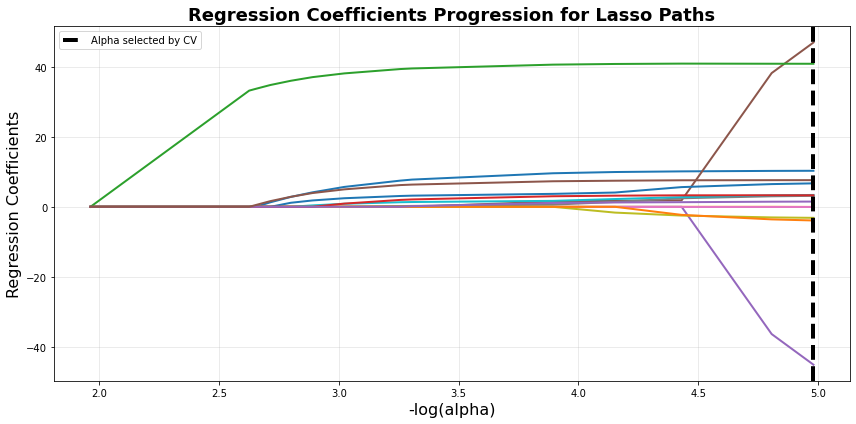

Representation:
- Each line represents a predictor variable
- As alpha increases (moving right), more coefficients shrink to zero
- The vertical dashed line shows the optimal alpha selected by cross-validation


In [10]:
#visualization of coefficient
m_log_alphas = -np.log10(model.alphas_)
plt.figure(figsize=(12, 6))
ax = plt.gca()
plt.plot(m_log_alphas, model.coef_path_.T, linewidth=2)
plt.axvline(-np.log10(model.alpha_), linestyle='--', color='k',
           label='Alpha selected by CV', linewidth=4)
plt.ylabel('Regression Coefficients', fontsize=16)
plt.xlabel('-log(alpha)', fontsize=16)
plt.title('Regression Coefficients Progression for Lasso Paths', fontsize=18, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print('Representation:')
print('- Each line represents a predictor variable')
print('- As alpha increases (moving right), more coefficients shrink to zero')
print('- The vertical dashed line shows the optimal alpha selected by cross-validation')

In [11]:
#cross validation
if hasattr(model, "cv_alphas_") and hasattr(model, "cv_mse_path_"):
    m_log_alphascv = -np.log10(model.cv_alphas_)
    plt.figure(figsize=(12, 6))
    plt.plot(m_log_alphascv, model.cv_mse_path_, ':', linewidth=1)
    plt.plot(m_log_alphascv, model.cv_mse_path_.mean(axis=-1), 'k', label='Average across the folds', linewidth=3)
    plt.axvline(-np.log10(model.alpha_), linestyle='--', color='red', label='Alpha selected by CV', linewidth=2)
    plt.legend(fontsize=11)
    plt.xlabel('-log(alpha)', fontsize=12)
    plt.ylabel('Mean Squared Error', fontsize=12)
    plt.title('Mean Squared Error on Each Fold of Cross-Validation', fontsize=14, fontweight='bold')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    print('Representation:')
    print('- Light lines show MSE for individual folds')
    print('- Bold black line shows average MSE across all folds')
    print('- Optimal alpha (red dashed line) minimizes average cross-validation error')
else:
    print("Cross-validation path attributes not found in this model instance.")
    


Cross-validation path attributes not found in this model instance.


In [12]:
#performance evaluation

train_error = mean_squared_error(tar_train, model.predict(pred_train))
test_error = mean_squared_error(tar_test, model.predict(pred_test))

print('Model Performance Metrics:')
print('='*60)
print('Mean Squared Error (MSE):')
print(f'  Training data MSE: {train_error:.4f}')
print(f'  Test data MSE: {test_error:.4f}')

#R-squared for training and test data
rsquared_train = model.score(pred_train, tar_train)
rsquared_test = model.score(pred_test, tar_test)

print('R-squared (Coefficient of Determination):')
print(f'  Training data R-squared: {rsquared_train:.4f}')
print(f'  Test data R-squared: {rsquared_test:.4f}')

print('' + '='*60)
print('Representation:')
print(f'- The model explains {rsquared_test*100:.2f}% of variance in the test data')
if abs(rsquared_train - rsquared_test) < 0.1:
    print('- Similar train/test performance suggests good generalization')
else:
    print('- Difference in train/test performance may indicate overfitting')

Model Performance Metrics:
Mean Squared Error (MSE):
  Training data MSE: 1.2320
  Test data MSE: 1.2397
R-squared (Coefficient of Determination):
  Training data R-squared: 0.2988
  Test data R-squared: 0.2323
Representation:
- The model explains 23.23% of variance in the test data
- Similar train/test performance suggests good generalization
